# Exploratory Notebook

This notebook will be just to play with the data to get a logical pipeline before building out python files, and integrating with streamlit for reporting


## Config

In [79]:

import os
import pandas as pd
import opensim as osim
import numpy as np
import matplotlib.pyplot as plt


data_path= "data"
assets_path= "assets"
outputs_path= "outputs"
c3dFileAdapter= osim.C3DFileAdapter()
trcFileAdapter= osim.TRCFileAdapter()
scaleTool = osim.ScaleTool()





## Data Loading

### Static

In [80]:


for file in os.listdir(data_path):
    if file.endswith(".c3d") and file.startswith("static"):
        static_c3d_file = os.path.join(data_path, file)



static_tables = c3dFileAdapter.read(static_c3d_file)
static_markersTable = c3dFileAdapter.getMarkersTable(static_tables)


def rotate_markers_z_to_y(static_markersTable): #Convert to opensim coordinate system
    for i in range(static_markersTable.getNumRows()):
        row = static_markersTable.getRowAtIndex(i)
        for j in range(row.size()):
            vec = row[j]
            x, y, z = vec[0], vec[1], vec[2]
            row[j] = osim.Vec3(x, z, -y)
        static_markersTable.setRowAtIndex(i, row)
    return static_markersTable

static_markersTable = rotate_markers_z_to_y(static_markersTable)
trcFileAdapter.write(static_markersTable, os.path.join(outputs_path, "static_markers.trc"))

static_forcesTable = c3dFileAdapter.getForcesTable(static_tables) #! Used to calculate mass


rows = []
for i in range(static_forcesTable.getNumRows()):
    row = static_forcesTable.getRowAtIndex(i)
    flat = []
    for j in range(row.size()):
        vec = row[j]
        flat.extend([vec[0], vec[1], vec[2]])
    rows.append(flat)

forces_matrix = np.array(rows)
fz1=forces_matrix[:, 2]
fz2=forces_matrix[:, 11]
fz3=forces_matrix[:, 20]
fz_total = fz1 + fz2 + fz3

mass= np.mean(fz_total) / 9.81




### Dynamic

In [81]:
for file in os.listdir(data_path):
    if file.endswith(".c3d") and file.startswith("movement"):
        dynamic_c3d_file = os.path.join(data_path, file)



dynamic_tables = c3dFileAdapter.read(dynamic_c3d_file)
dynamic_markersTable = c3dFileAdapter.getMarkersTable(dynamic_tables)


def rotate_markers_z_to_y(dynamic_markersTable): #Convert to opensim coordinate system
    for i in range(dynamic_markersTable.getNumRows()):
        row = dynamic_markersTable.getRowAtIndex(i)
        for j in range(row.size()):
            vec = row[j]
            x, y, z = vec[0], vec[1], vec[2]
            row[j] = osim.Vec3(x, z, -y)
        dynamic_markersTable.setRowAtIndex(i, row)
    return dynamic_markersTable

dynamic_markersTable = rotate_markers_z_to_y(dynamic_markersTable)
trcFileAdapter.write(dynamic_markersTable, os.path.join(outputs_path, "dynamic_markers.trc"))


dynamic_forcesTable = c3dFileAdapter.getForcesTable(dynamic_tables) #! Will be used for inverse dynamics

In [82]:
osimModel = osim.Model(os.path.join(assets_path, "testing.osim"))


# Time range from static markers table
t_start = static_markersTable.getIndependentColumn()[0]
t_end = static_markersTable.getIndependentColumn()[-1]
timeRange = osim.ArrayDouble()
timeRange.set(0, t_start)
timeRange.set(1, t_end)

# Pathing
static_trc_path = os.path.join(outputs_path, "static_markers.trc")
scaled_model_path = os.path.join(outputs_path, "scaled_model.osim")
scaled_model_placed_path = os.path.join(outputs_path, "scaled_model_placed.osim")


scaleTool.setSubjectMass(abs(mass)) 
scaleTool.getGenericModelMaker().setModelFileName(os.path.join(assets_path, "testing.osim")) # Model scaler 
modelScaler = scaleTool.getModelScaler() 
modelScaler.setApply(True) 
modelScaler.setMarkerFileName(static_trc_path)
modelScaler.setTimeRange(timeRange) 
modelScaler.setPreserveMassDist(True) 
modelScaler.setOutputModelFileName(scaled_model_path) 
modelScaler.processModel(osimModel, "", abs(mass))


# Marker placer
scaled_model = osim.Model(scaled_model_path)
markerPlacer = scaleTool.getMarkerPlacer()
markerPlacer.setApply(True)
markerPlacer.setStaticPoseFileName(static_trc_path)
markerPlacer.setTimeRange(timeRange)
markerPlacer.setOutputModelFileName(scaled_model_placed_path)
markerPlacer.setMaxMarkerMovement(-1)
markerPlacer.processModel(scaled_model)

scaled_model.printToXML(scaled_model_path)

#IK tool
scaled_placed_model= osim.Model(os.path.join(outputs_path, "scaled_model_placed.osim"))

ikTool = osim.InverseKinematicsTool()
ikTool.setModel(scaled_placed_model)
ikTool.setMarkerDataFileName(os.path.join(outputs_path, "dynamic_markers.trc"))
ikTool.setOutputMotionFileName(os.path.join(outputs_path, "ik_motion.mot"))
ikTool.run()



True

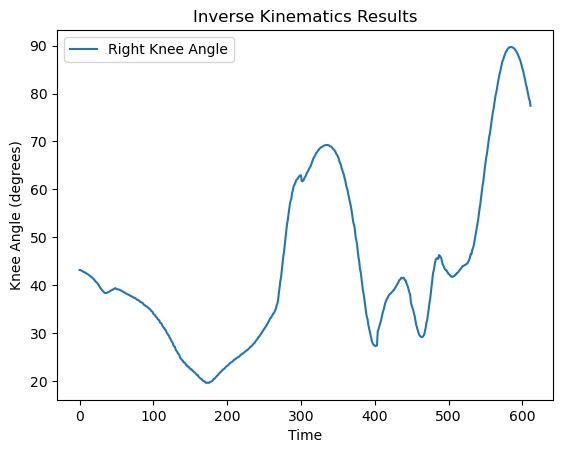

In [83]:

def load_mot(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    # Find end of header
    for i, line in enumerate(lines):
        if "endheader" in line.lower():
            start_idx = i + 1
            break

    # Load directly with pandas
    df = pd.read_csv(
        file_path,
        sep='\t',
        skiprows=start_idx,
        header=0   # first row after header is column names
    )

    return df

df = load_mot(os.path.join(outputs_path, "ik_motion.mot"))

plt.plot(df['knee_angle_r'], label='Right Knee Angle')
plt.xlabel('Time')
plt.ylabel('Knee Angle (degrees)')
plt.title('Inverse Kinematics Results')
plt.legend()
plt.show()
